# Chapter 2: Introduction to Self-Attention Mechanisms

This notebook walks through a step-by-step implementation of the self-attention mechanism, which is the core building block of Transformer-based models. We will calculate the attention weights and context vectors manually to understand the underlying math.

## 1. Environment Setup

First, let's verify that PyTorch is correctly installed in our environment.

In [2]:
from importlib.metadata import version

print("torch version:", version("torch"))

torch version: 2.12.0


## 2. Input Sequence Representation (Embeddings)

We define a toy sequence of 6 words: *"Your journey starts with one step"*.
Each word is represented by a 3-dimensional embedding vector. These form our `inputs` tensor of shape `(6, 3)`.

In [3]:
import torch

# Defining input embeddings for 6 tokens (3-dimensional vectors)
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # "Your"    (x^1)
   [0.55, 0.87, 0.66], # "journey" (x^2)
   [0.57, 0.85, 0.64], # "starts"  (x^3)
   [0.22, 0.58, 0.33], # "with"    (x^4)
   [0.77, 0.25, 0.10], # "one"     (x^5)
   [0.05, 0.80, 0.55]] # "step"    (x^6)
)

## 3. Extracting Token Embedding Vectors

Let's assign descriptive variable names to each individual embedding vector in our sequence.

In [4]:
# Assigning individual variables to each token vector for clarity
word_your = inputs[0]      # x^1
word_journey = inputs[1]   # x^2 (This will be our query word)
word_starts = inputs[2]    # x^3
word_with = inputs[3]      # x^4
word_one = inputs[4]       # x^5
word_step = inputs[5]      # x^6

## 4. Self-Attention Mechanism Without Trainable Weights

A basic self-attention mechanism computes attention weights by measuring the raw similarity (e.g. dot product) between tokens directly, without mapping them using weight parameter matrices.

### 4.1 Computing Raw Attention Scores (Iteratively)

We calculate the similarity (attention scores) between the query token *"journey"* ($x^2$) and all other tokens in the sequence ($x^i$) using the dot product.

In [5]:
# Initialize an empty tensor to hold raw attention scores
word_journey_attn_score = torch.empty(inputs.shape[0])
print(f"Initialize word_journey_attn_score:     {word_journey_attn_score}")

# Calculate raw attention scores via dot product
for i, x_i in enumerate(inputs):
    # dot product (transpose not necessary here since they are 1-dim vectors)
    word_journey_attn_score[i] = torch.dot(x_i, word_journey) 

print(f"Attention Score of word 'journey':      {word_journey_attn_score}")

Initialize word_journey_attn_score:     tensor([0., 0., 0., 0., 0., 0.])
Attention Score of word 'journey':      tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


### 4.2 Simple Division-by-Sum Normalization

First, let's normalize the attention scores using a simple division-by-sum method. Note that this doesn't handle negative scores well and fails to highlight the most relevant values exponentially.

In [6]:
# Naive normalization: divide each score by the sum of all scores
attn_weights_2_tmp = word_journey_attn_score / word_journey_attn_score.sum()

print(f"Attention weights (Naive):              {attn_weights_2_tmp}")
print(f"Sum:                                    {attn_weights_2_tmp.sum()}")

Attention weights (Naive):              tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum:                                    1.0000001192092896


### 4.3 Exponentiated Normalization via Naive Softmax

To convert raw attention scores into attention weights (probabilities summing to 1), we apply the Softmax function.

In [7]:
# Naive implementation of the softmax function
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

word_journey_attn_score_softmax_naive = softmax_naive(word_journey_attn_score)

print(f"Attention weights (Naive Softmax):      {word_journey_attn_score_softmax_naive}")
print(f"Attention weights Sum:                  {word_journey_attn_score_softmax_naive.sum()}")

Attention weights (Naive Softmax):      tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Attention weights Sum:                  1.0


### 4.4 Normalizing via PyTorch's Built-in Softmax

Now let's compare our naive implementation with PyTorch's built-in `torch.softmax`.

In [8]:
# Apply PyTorch's built-in softmax (more numerically stable)
word_journey_attn_score_softmax = torch.softmax(word_journey_attn_score, dim=0)

print(f"Attention weights (PyTorch Softmax):    {word_journey_attn_score_softmax}")
print(f"Attention weight sum:                   {word_journey_attn_score_softmax.sum()}")

Attention weights (PyTorch Softmax):    tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Attention weight sum:                   1.0


### 4.5 Computing the Context Vector for a Single Token

The context vector is calculated as a weighted sum of all input embedding vectors, where the weights are the normalized attention weights.

In [9]:
# Initialize context vector z^2 with zeros
context_vec_word_journey = torch.zeros(word_journey.shape)
print(f"Initial context vector:                 {context_vec_word_journey}")

# Compute the weighted sum of input vectors
for i, x_i in enumerate(inputs):
    context_vec_word_journey += word_journey_attn_score_softmax[i] * x_i

print(f"Context vector for 'journey':           {context_vec_word_journey}")

Initial context vector:                 tensor([0., 0., 0.])
Context vector for 'journey':           tensor([0.4419, 0.6515, 0.5683])


### 4.6 Computing Attention Scores for All Tokens (All-Pairs Attention Matrix)

We calculate the similarity (attention scores) between every pair of words in the sequence. We compare the iterative loop approach with the vectorized matrix multiplication approach (`inputs @ inputs.T`).

In [10]:
# 1. Compute attention scores iteratively using loops
attn_scores_all_words = torch.empty(inputs.shape[0], inputs.shape[0])

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores_all_words[i, j] = torch.dot(x_i, x_j)

print(f"Attention Scores (Iterative Loop):\n{attn_scores_all_words}\n")

# 2. Vectorized approach using matrix multiplication
attn_scores_all_matrix = inputs @ inputs.T
print(f"Attention Scores (Matrix Multiplication):\n{attn_scores_all_matrix}\n")

# Verify both approaches produce identical results
is_same = torch.allclose(attn_scores_all_words, attn_scores_all_matrix)
print("Are both results identical?:", is_same)

Attention Scores (Iterative Loop):
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

Attention Scores (Matrix Multiplication):
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

Are both results identical?: True


### 4.7 Computing Attention Weights for All Tokens

We normalize the raw attention scores row-wise using the softmax function. Normalizing along `dim=-1` ensures each word's attention weights sum up to 1.

In [11]:
# Apply softmax across columns (dim=-1) to normalize weights for each query word
attn_weights_all_words = torch.softmax(attn_scores_all_matrix, dim=-1)
print(f"Normalized attention weights matrix:\n{attn_weights_all_words}\n")

# Verify that each row sums to 1
row_sums = attn_weights_all_words.sum(dim=-1)
print(f"Sum of attention weights for each row:   {row_sums}")

Normalized attention weights matrix:
tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

Sum of attention weights for each row:   tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


### 4.8 Computing Context Vectors for All Tokens

We compute the context vectors for all words in parallel by multiplying the attention weights matrix by the input embedding matrix.

In [12]:
# Compute context vectors for all words in one step using matrix multiplication
context_vecs_all_words = attn_weights_all_words @ inputs
print(f"Context vector of all words:\n{context_vecs_all_words}\n")

Context vector of all words:
tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])



### 4.9 Visualizing All-Pairs Attention Scores and Weights

We visualize the raw attention scores and normalized attention weights matrices side-by-side using heatmaps. We use Python lists to avoid any issues with NumPy environments.

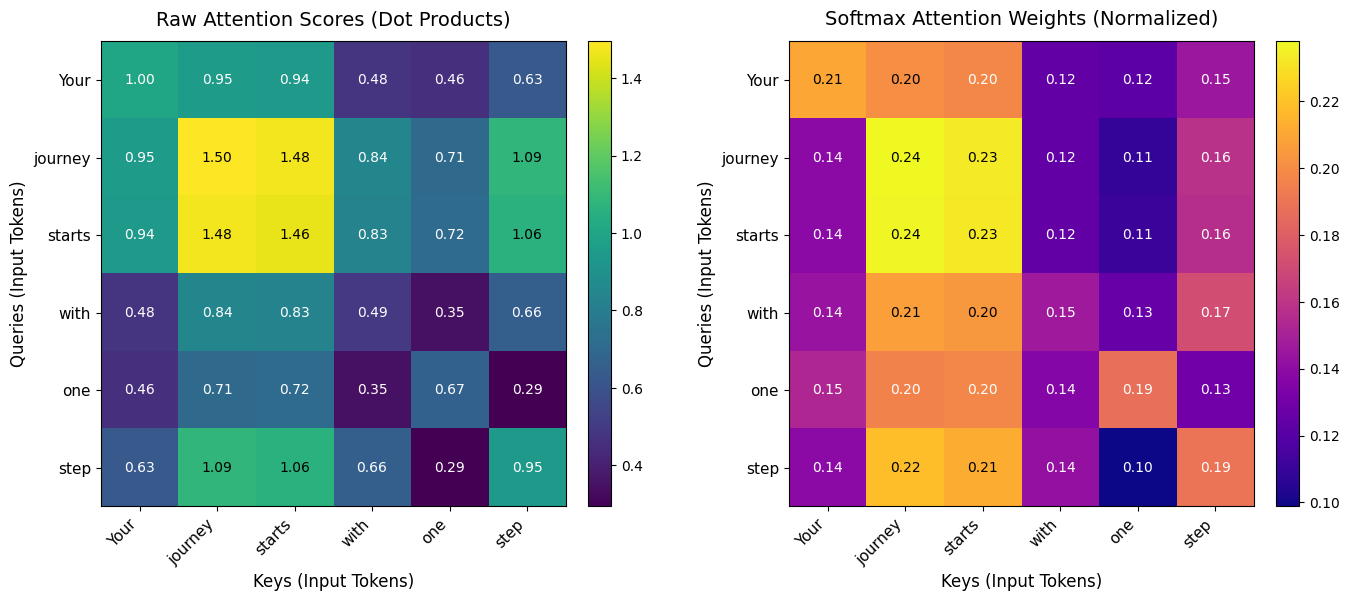

In [13]:
import matplotlib.pyplot as plt

# Define labels representing our sequence tokens
words = ["Your", "journey", "starts", "with", "one", "step"]

# Convert scores tensor to standard Python list of lists for plotting
scores_list = attn_scores_all_matrix.tolist()
weights_list = attn_weights_all_words.tolist()

# Create heatmaps side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Raw Attention Scores Heatmap
im1 = axes[0].imshow(scores_list, cmap="viridis")
axes[0].set_title("Raw Attention Scores (Dot Products)", fontsize=14, pad=12)
axes[0].set_xticks(list(range(6)))
axes[0].set_yticks(list(range(6)))
axes[0].set_xticklabels(words, rotation=45, ha="right", fontsize=11)
axes[0].set_yticklabels(words, fontsize=11)
axes[0].set_xlabel("Keys (Input Tokens)", fontsize=12)
axes[0].set_ylabel("Queries (Input Tokens)", fontsize=12)
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Annotate cell values in raw scores map
for i in range(6):
    for j in range(6):
        axes[0].text(j, i, f"{scores_list[i][j]:.2f}",
                     ha="center", va="center", 
                     color="white" if scores_list[i][j] < 1.0 else "black")

# Plot 2: Softmax Attention Weights Heatmap
im2 = axes[1].imshow(weights_list, cmap="plasma")
axes[1].set_title("Softmax Attention Weights (Normalized)", fontsize=14, pad=12)
axes[1].set_xticks(list(range(6)))
axes[1].set_yticks(list(range(6)))
axes[1].set_xticklabels(words, rotation=45, ha="right", fontsize=11)
axes[1].set_yticklabels(words, fontsize=11)
axes[1].set_xlabel("Keys (Input Tokens)", fontsize=12)
axes[1].set_ylabel("Queries (Input Tokens)", fontsize=12)
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# Annotate cell values in weights map
for i in range(6):
    for j in range(6):
        axes[1].text(j, i, f"{weights_list[i][j]:.2f}",
                     ha="center", va="center", 
                     color="white" if weights_list[i][j] < 0.2 else "black")

plt.tight_layout()
plt.show()

## 5. Implementing Self-Attention With Trainable Weights

Modern Transformer self-attention uses projection weight matrices to compute Query ($Q$), Key ($K$), and Value ($V$) representations of the inputs. These weights are trainable parameters that allow the model to learn different projection spaces.

### 5.1 Defining Embedding Dimensions

We set up input size $d_{\text{in}}=3$ and target output projection size $d_{\text{out}}=2$.

In [14]:
word_journey = inputs[1]        # second input element ("journey")
emb_dim_in = inputs.shape[1]    # input embedding size (d_in = 3)
emb_dim_out = 2                 # output embedding size (d_out = 2)

print(f"Query Token Vector (x_2):           {word_journey}")
print(f"Input Dimension (d_in):             {emb_dim_in}")
print(f"Output Dimension (d_out):           {emb_dim_out}")

Query Token Vector (x_2):           tensor([0.5500, 0.8700, 0.6600])
Input Dimension (d_in):             3
Output Dimension (d_out):           2


### 5.2 Initializing Weight Projection Matrices

We initialize three weight parameter matrices ($W_q, W_k, W_v$). These project our input embeddings into query, key, and value vectors.

In [15]:
torch.manual_seed(123)

# Initialize W_query, W_key, W_value as trainable weight matrices
W_query = torch.nn.Parameter(torch.rand(emb_dim_in, emb_dim_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(emb_dim_in, emb_dim_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(emb_dim_in, emb_dim_out), requires_grad=False)

print(f"W_query:                            \n{W_query}\n")
print(f"W_key:                              \n{W_key}\n")
print(f"W_value:                            \n{W_value}\n")

W_query:                            
Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])

W_key:                              
Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])

W_value:                            
Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]])



### 5.3 Projecting a Single Token Embedding

For our query token *"journey"* ($x^2$), we project its embedding vector into Query ($q^2$), Key ($k^2$), and Value ($v^2$) spaces using the initialized weight matrices.

In [16]:
# Project query token vector x_2 ("journey") to Query, Key, and Value spaces
journey_query = word_journey @ W_query
journey_keys = word_journey @ W_key 
journey_values = word_journey @ W_value

print(f"W_query.shape:                      {W_query.shape}")
print(f"W_key.shape:                        {W_key.shape}")
print(f"W_value.shape:                      {W_value.shape}\n")

print(f"journey_query.shape:                {journey_query.shape}")
print(f"journey_keys.shape:                 {journey_keys.shape}")
print(f"journey_values.shape:               {journey_values.shape}\n")

print(f"journey_query (q^2):                {journey_query}")
print(f"journey_keys (k^2):                 {journey_keys}")
print(f"journey_values (v^2):               {journey_values}")

W_query.shape:                      torch.Size([3, 2])
W_key.shape:                        torch.Size([3, 2])
W_value.shape:                      torch.Size([3, 2])

journey_query.shape:                torch.Size([2])
journey_keys.shape:                 torch.Size([2])
journey_values.shape:               torch.Size([2])

journey_query (q^2):                tensor([0.4306, 1.4551])
journey_keys (k^2):                 tensor([0.4433, 1.1419])
journey_values (v^2):               tensor([0.3951, 1.0037])


### 5.4 Self-Attention Score Check

We check the self-attention raw score for the token *"journey"* relative to itself by calculating the dot product of its Query vector ($q^2$) and Key vector ($k^2$).

In [17]:
# Calculate raw self-attention score for x_2 against x_2
attn_score_journey_score = journey_query.dot(journey_keys)
print("Self-attention raw score for 'journey':", attn_score_journey_score)

Self-attention raw score for 'journey': tensor(1.8524)


### 5.5 Projecting All Input Tokens in Parallel

Instead of projecting tokens one by one, we can project the entire sequence matrix of input embeddings ($X$) into Query, Key, and Value space matrices ($Q, K, V$) simultaneously.

In [18]:
# Project all inputs to Query, Key, and Value space matrices
all_words_query = inputs @ W_query
all_words_keys = inputs @ W_key 
all_words_values = inputs @ W_value

print(f"all_words_query.shape:              {all_words_query.shape}")
print(f"all_words_keys.shape:               {all_words_keys.shape}")
print(f"all_words_values.shape:             {all_words_values.shape}\n")

print(f"all_words_query (Q):\n{all_words_query}\n")
print(f"all_words_keys (K):\n{all_words_keys}\n")
print(f"all_words_values (V):\n{all_words_values}")

all_words_query.shape:              torch.Size([6, 2])
all_words_keys.shape:               torch.Size([6, 2])
all_words_values.shape:             torch.Size([6, 2])

all_words_query (Q):
tensor([[0.2309, 1.0966],
        [0.4306, 1.4551],
        [0.4300, 1.4343],
        [0.2355, 0.7990],
        [0.2983, 0.6565],
        [0.2568, 1.0533]])

all_words_keys (K):
tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]])

all_words_values (V):
tensor([[0.1855, 0.8812],
        [0.3951, 1.0037],
        [0.3879, 0.9831],
        [0.2393, 0.5493],
        [0.1492, 0.3346],
        [0.3221, 0.7863]])


### 5.6 Computing Raw Attention Scores relative to Query Token

We calculate the raw attention scores for our query token *"journey"* against all other key tokens in the sequence using a matrix multiplication of its query vector ($q^2$) and the transpose of the key matrix ($K^T$).

In [19]:
# Compute raw attention scores (q^2 @ K^T)
attn_scores_word_journey = journey_query @ all_words_keys.T
print("Raw attention scores for 'journey':", attn_scores_word_journey)

Raw attention scores for 'journey': tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


### 5.7 Normalization using Scaled Softmax

In scaled dot-product attention, we divide the raw scores by $\sqrt{d_k}$ (the square root of the Key embedding dimension). This scaling prevents the dot products from growing excessively large for high dimensions, which could push the softmax function into regions with extremely small gradients.

In [20]:
# Get Key embedding dimension size (d_k)
d_k = all_words_keys.shape[1]

print(f"d_k: {d_k}")

# Compute attention weights using scaled softmax normalization
attn_weights_word_journey = torch.softmax(attn_scores_word_journey / d_k**0.5, dim=-1)
print("Scaled attention weights (Softmax):", attn_weights_word_journey)

d_k: 2
Scaled attention weights (Softmax): tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


### 5.8 Computing the Final Context Vector

We obtain the final context vector $z^2$ for the token *"journey"* by taking the weighted sum of all projected Value vectors ($V$) using the normalized attention weights.

In [21]:
# Compute context vector z^2 as a weighted sum of Values matrix (weights @ V)
context_vec_word_journey = attn_weights_word_journey @ all_words_values
print("Final Context Vector for 'journey':", context_vec_word_journey)

Final Context Vector for 'journey': tensor([0.3061, 0.8210])


## 6. Implementing a Compact Self-Attention Class

We can compile the operations into a compact PyTorch `nn.Module` class. We implement two versions: parameter-based projection matrices and built-in PyTorch Linear layers.

### 6.1 Version 1: Parameter-Based Projection Matrices

Here, we store our trainable weights using PyTorch `nn.Parameter` tensors, which register the weights in the module for optimization during backpropagation.

In [22]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        # Initialize projection matrices as trainable Parameter tensors
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        # Project inputs to Query, Key, and Value spaces
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value
        
        # Compute scaled attention scores
        attn_scores = queries @ keys.T 
        d_k = keys.shape[-1]
        attn_weights = torch.softmax(
            attn_scores / d_k**0.5, dim=-1
        )

        # Compute final context vectors
        context_vec = attn_weights @ values
        return context_vec

# Test SelfAttention_v1
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(emb_dim_in, emb_dim_out)
print("SelfAttention_v1 output:\n", sa_v1(inputs))

SelfAttention_v1 output:
 tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


### 6.2 Version 2: Linear-Layer-Based Projection

We can also implement self-attention using PyTorch's built-in `nn.Linear` layers, which project inputs into Query, Key, and Value vectors. `nn.Linear` is standard in modern models and behaves similarly but does not require manual transpose during multiplication.

In [23]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        # Use nn.Linear layers for projecting embedding representations
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        # Perform forward pass projection
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        # Compute scaled attention scores
        attn_scores = queries @ keys.T
        d_k = keys.shape[-1]
        attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)

        # Compute final context vectors
        context_vec = attn_weights @ values
        return context_vec

# Test SelfAttention_v2
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(emb_dim_in, emb_dim_out)
print("SelfAttention_v2 output:\n", sa_v2(inputs))

SelfAttention_v2 output:
 tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


### 6.3. Hiding future words with causal attention

In [24]:
# Reuse sa_v2 linear weights to project inputs
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs) 
attn_scores = queries @ keys.T

# Compute normalized weights
d_k = keys.shape[-1]
attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)
print("Attention Weights:\n", attn_weights)

Attention Weights:
 tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [25]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [26]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [27]:
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


In [28]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [29]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


### 6.4 Masking additional attention weights with dropout

In [30]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5) # dropout rate of 50%
example = torch.ones(6, 6) # create a matrix of ones

print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [31]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


### 6.5 Implementing a compact causal self-attention class

In [37]:
batch = torch.stack((inputs, inputs), dim=0)

print(batch.shape) # 2 inputs with 6 tokens each, and each token has embedding dimension 3

torch.Size([2, 6, 3])


In [33]:
class CausalAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length,
                 dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(emb_dim_in, emb_dim_out, bias=qkv_bias)
        self.W_key   = nn.Linear(emb_dim_in, emb_dim_out, bias=qkv_bias)
        self.W_value = nn.Linear(emb_dim_in, emb_dim_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout) # New
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # New

    def forward(self, x):
        b, num_tokens, d_in = x.shape # New batch dimension b
        # For inputs where `num_tokens` exceeds `context_length`, this will result in errors
        # in the mask creation further below.
        # In practice, this is not a problem since the LLM (chapters 4-7) ensures that inputs  
        # do not exceed `context_length` before reaching this forward method. 
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2) # Changed transpose
        attn_scores.masked_fill_(  # New, _ ops are in-place
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)  # `:num_tokens` to account for cases where the number of tokens in the batch is smaller than the supported context_size
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights) # New

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(123)

context_length = batch.shape[1]
ca = CausalAttention(emb_dim_in, emb_dim_out, context_length, 0.0)

context_vecs = ca(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


## 7. Extending single-head attention to multi-head attention

In [34]:
class MultiHeadAttentionWrapper(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) 
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)


torch.manual_seed(123)

context_length = batch.shape[1] # This is the number of tokens
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)

context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])
